# **Notebook 3 — ML Pipeline: Phases 1 to 4**

This notebook implements the end-to-end machine learning pipeline for Carrefour customer segmentation, picking up directly from the clean dataset produced in Notebook 2. The goal is to discover **organic customer tribes** — behavioural groups defined purely by what customers buy and how they shop, with no demographic profiling.

## Pipeline Overview

| Phase | Section | Step | Method |
|---|---|---|---|
| 1 | 5 | Product Embeddings | Word2Vec / Item2Vec (cart = sentence, product = word; single-item baskets excluded) |
| 2 | 6 | Customer Vectors | Frequency-weighted + time-decay (60-day half-life) aggregation |
| 2 | 6.6 | Store Affinity Features | Per-customer spend share per store format (new) |
| 3 | 7 | Dimensionality Reduction | UMAP on 100D vectors + promo_rate + store shares (primary) vs PCA (baseline) |
| 4 | 8 | Clustering | HDBSCAN vs K-Means — empirical comparison, data decides winner |
| 4 | 8.5–8.6 | Tribe Profiles | KPI + top products for both methods; primary deliverable from empirical winner |

## *Setup and Import*

In [1]:
import sys, warnings, logging, time
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
warnings.filterwarnings("ignore")
logging.basicConfig(format="%(asctime)s %(levelname)s %(message)s",
                    level=logging.INFO, datefmt="%H:%M:%S")

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from src.config import DATA_PROCESSED, OUTPUTS

OUTPUTS.mkdir(parents=True, exist_ok=True)

# ── Confirm Notebook 2 outputs exist before proceeding ────────────────────────
# All three files are produced by 02_pre-analysis.ipynb.
# If any are missing, run that notebook first.
required = {
    "df_combined.parquet"  : "Section 3 (Notebook 2 — 02_pre-analysis.ipynb)",
    "customer_kpis.parquet": "Section 4.1 (Notebook 2 — 02_pre-analysis.ipynb)",
    "quality_report.json"  : "Section 2 (Notebook 2 — 02_pre-analysis.ipynb)",
}
all_ok = True
for fname, source in required.items():
    path = DATA_PROCESSED / fname
    if path.exists():
        size = path.stat().st_size
        unit = "GB" if size > 1e9 else "MB"
        size_disp = size / (1024**3 if unit == "GB" else 1024**2)
        print(f"  OK  {fname} ({size_disp:.1f} {unit})")
    else:
        print(f"  MISSING  {fname}  ← run {source} first")
        all_ok = False

if not all_ok:
    raise FileNotFoundError(
        "One or more Notebook 2 outputs are missing. "
        "Run 02_pre-analysis.ipynb from Section 0 through Section 5 before proceeding."
    )

print("\nAll Notebook 2 outputs confirmed. Ready to proceed.")

  OK  df_combined.parquet (9.8 GB)
  OK  customer_kpis.parquet (121.4 MB)
  OK  quality_report.json (0.0 MB)

All Notebook 2 outputs confirmed. Ready to proceed.


## **Section 5 — Phase 1: Product Embeddings (Word2Vec / Item2Vec)**

**Core idea**: treat each shopping basket as a sentence and each product ID as a word. Word2Vec learns vector representations such that products frequently bought together land geometrically close in 100-dimensional space. The resulting product vectors are the foundation for every downstream step — customer vectors, dimensionality reduction, and clustering all inherit their quality.

### Why Item2Vec works here
- Co-purchase context is the strongest behavioural signal in transactional data
- Skip-gram (sg=1) predicts the context from the product — better than CBOW for rare items
- window=5 means "within the same basket" for most carts (median basket ≈ 10 items)
- min_count=3 drops products that appear in fewer than 3 baskets — too rare to embed reliably
- Single-item baskets are excluded: they generate zero co-purchase pairs and only add noise

### Pipeline steps
| Step | Output | Memory strategy |
|---|---|---|
| 5.1 Build basket sentences | `basket_sentences.parquet` | Streaming group_by — never materialises 190M rows |
| 5.2 Train Word2Vec | `models/word2vec_product.model` | Basket file loaded once, streamed per epoch |
| 5.3 Save embeddings | `product_embeddings.parquet` | ~36 MB — trivial |
| 5.4 Sanity check | stdout | Nearest-neighbour lookup, no extra data needed |

All steps are cached — re-running any cell is instant after the first run.

In [2]:
# ── Section 5 entry point — safe to run even if Sections 1–3 were skipped ─────
import sys, logging
from pathlib import Path

# Locate project root regardless of where Jupyter was launched from
_root = next(
    p for p in [Path.cwd(), Path.cwd().parent]
    if (p / "src" / "config.py").exists()
)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

logging.basicConfig(format="%(asctime)s %(levelname)s %(message)s",
                    level=logging.INFO, datefmt="%H:%M:%S")

from src.embeddings import (
    build_basket_sentences,
    train_word2vec,
    save_embeddings,
    sanity_check,
)
from src.config import DATA_PROCESSED, MODELS

# Re-attach df_articles if this session skipped the earlier sections
if "df_articles" not in vars():
    from src.data_loader import load_maestra_articulos
    df_articles = load_maestra_articulos()
    print(f"Loaded df_articles: {len(df_articles):,} rows")
else:
    print(f"df_articles already in session: {len(df_articles):,} rows")

print("Section 5 imports OK")

Loaded df_articles: 893,944 rows
Section 5 imports OK


### 5.1 Build Basket Sentences

Group the 190 M clean transaction lines by ticket number. Each basket becomes a list of product IDs — the "sentence" Word2Vec will train on. This reduces 190 M rows to ~20 M baskets and is cached immediately so it never runs twice.

16:08:41 INFO Building basket sentences from df_combined.parquet ...


16:11:32 INFO Saved 17,903,693 baskets → basket_sentences.parquet  (625 MB on disk)


Baskets built           :   17,903,693
Median items per basket :    7.0
Mean items per basket   :   10.5
p25 / p75               : 4 / 13
p99 (large baskets)     : 54
Single-item baskets     : 0.0%


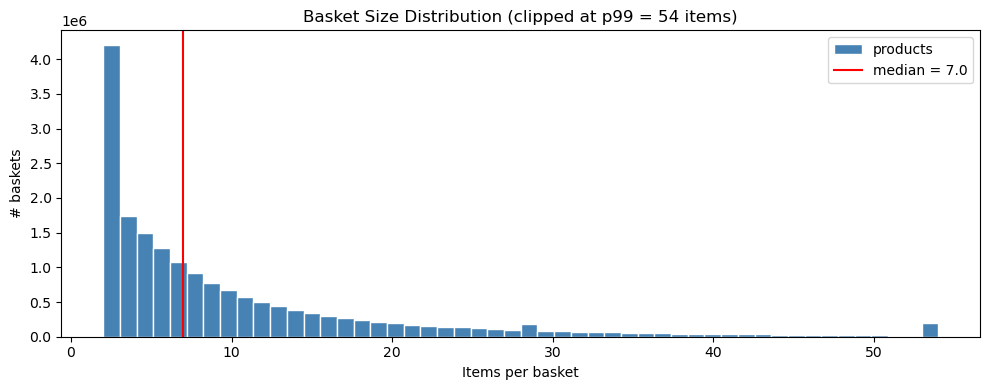

In [3]:
# ── 5.1 Build basket sentences ────────────────────────────────────────────────
basket_path = build_basket_sentences()   # cached after first run

# ── Basket size distribution ──────────────────────────────────────────────────
baskets      = pl.read_parquet(basket_path)
basket_sizes = baskets["products"].list.len()   # Polars Series of ints

p99_size = int(basket_sizes.quantile(0.99))

size_stats = {
    "n_baskets":       len(baskets),
    "median_size":     float(basket_sizes.median()),
    "mean_size":       float(basket_sizes.mean()),
    "p25":             float(basket_sizes.quantile(0.25)),
    "p75":             float(basket_sizes.quantile(0.75)),
    "p99":             float(p99_size),
    "single_item_pct": float((basket_sizes == 1).mean() * 100),
}

print(f"Baskets built           : {size_stats['n_baskets']:>12,}")
print(f"Median items per basket : {size_stats['median_size']:>6.1f}")
print(f"Mean items per basket   : {size_stats['mean_size']:>6.1f}")
print(f"p25 / p75               : {size_stats['p25']:.0f} / {size_stats['p75']:.0f}")
print(f"p99 (large baskets)     : {size_stats['p99']:.0f}")
print(f"Single-item baskets     : {size_stats['single_item_pct']:.1f}%")

fig, ax = plt.subplots(figsize=(10, 4))
# Polars clip uses upper_bound= (not upper= like pandas)
(
    basket_sizes
    .clip(upper_bound=p99_size)
    .to_pandas()
    .plot.hist(bins=50, ax=ax, color="steelblue", edgecolor="white",
               title=f"Basket Size Distribution (clipped at p99 = {p99_size} items)")
)
ax.set_xlabel("Items per basket")
ax.set_ylabel("# baskets")
ax.axvline(size_stats["median_size"], color="red", lw=1.5,
           label=f"median = {size_stats['median_size']:.1f}")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS / "embedding_basket_sizes.png", dpi=120)
plt.show()

del baskets, basket_sizes   # free RAM before training

### 5.2 Train Word2Vec

First run takes **15–30 minutes** (20 M baskets × 10 epochs × skip-gram). Every subsequent run loads the saved model from disk in under a second. Do not interrupt mid-training — the cache will be incomplete and gensim will raise an error on load. If that happens, delete `models/word2vec_product.model` and re-run.

In [4]:
# ── 5.2 Train Word2Vec ────────────────────────────────────────────────────────
# workers=4 uses 4 CPU threads; reduce to 2 if the machine struggles during training
# CBOW (sg=0) + 5 epochs: expected runtime ~20-40 min on first run
import time
_t0 = time.time()

w2v_model = train_word2vec(workers=4)

_elapsed = time.time() - _t0
print(f"\nTraining complete in {_elapsed/60:.1f} min")
print(f"Vocabulary size : {len(w2v_model.wv):,} products")
print(f"Vector size     : {w2v_model.wv.vector_size}")

16:11:57 INFO Loading basket sentences into memory (one-time) ...
16:11:58 INFO   17,903,693 baskets loaded
16:11:58 INFO Training Word2Vec | 17,903,693 baskets | vector_size=100  window=5  min_count=3  epochs=10  sg=1  workers=4
16:11:58 INFO collecting all words and their counts
16:11:59 INFO PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
16:11:59 INFO PROGRESS: at sentence #10000, processed 105006 words, keeping 21968 word types
16:11:59 INFO PROGRESS: at sentence #20000, processed 208556 words, keeping 29377 word types
16:11:59 INFO PROGRESS: at sentence #30000, processed 314223 words, keeping 34192 word types
16:11:59 INFO PROGRESS: at sentence #40000, processed 419498 words, keeping 37868 word types
16:11:59 INFO PROGRESS: at sentence #50000, processed 523790 words, keeping 40651 word types
16:11:59 INFO PROGRESS: at sentence #60000, processed 628616 words, keeping 43033 word types
16:11:59 INFO PROGRESS: at sentence #70000, processed 734974 words, keeping 4507


Training complete in 63.8 min
Vocabulary size : 100,079 products
Vector size     : 100


### 5.3 Save Embeddings & Coverage Check

Export the trained vectors to parquet and verify what fraction of the 117 K catalogue products received an embedding. Products below `min_count=3` are excluded — they appear in too few baskets for Word2Vec to learn a meaningful representation. These will be handled in Phase 2 by falling back to their sector centroid.

In [5]:
# ── 5.3 Save embeddings & coverage check ─────────────────────────────────────
product_embeddings = save_embeddings(w2v_model)

# Three populations to distinguish:
#   catalogue     = all products in the master table (many never purchased)
#   transacted    = products that appear in at least 1 basket in df_combined
#   with_embedding = products with >= min_count baskets → got a Word2Vec vector
n_catalogue      = df_articles["idarticu"].n_unique()
n_transacted     = (
    pl.scan_parquet(DATA_PROCESSED / "basket_sentences.parquet")
    .explode("products")
    .select(pl.col("products").n_unique())
    .collect(engine="streaming")
    .item()
)
n_with_embedding = len(product_embeddings)
n_below_min      = n_transacted - n_with_embedding
n_never_bought   = n_catalogue - n_transacted

print("=" * 58)
print("  PRODUCT EMBEDDING COVERAGE")
print("=" * 58)
print(f"  Full catalogue (master table)   : {n_catalogue:>10,}")
print(f"  Never purchased in 6 months     : {n_never_bought:>10,}  "
      f"({n_never_bought/n_catalogue*100:.1f}% of catalogue — not in transactions at all)")
print(f"  ─────────────────────────────────────────────────────")
print(f"  Ever purchased (≥1 basket)      : {n_transacted:>10,}")
print(f"    Below min_count (<3 baskets)  : {n_below_min:>10,}  "
      f"({n_below_min/n_transacted*100:.1f}% of purchased — too rare to embed)")
print(f"    With embedding  (≥3 baskets)  : {n_with_embedding:>10,}  "
      f"({n_with_embedding/n_transacted*100:.1f}% of purchased)")
print("=" * 58)
print(f"\n  Effective Phase 2 coverage: {n_with_embedding/n_transacted*100:.1f}% of purchased products")
print(f"  Products below min_count will fall back to their sector centroid in Phase 2.")
print(f"\n  Embedding shape : {n_with_embedding:,} products × {w2v_model.wv.vector_size} dims")
print(f"  File size       : {(DATA_PROCESSED / 'product_embeddings.parquet').stat().st_size / 1024**2:.1f} MB")

17:16:06 INFO Saved 100,079 embeddings → product_embeddings.parquet  (35.7 MB on disk)


  PRODUCT EMBEDDING COVERAGE
  Full catalogue (master table)   :    893,944
  Never purchased in 6 months     :    777,891  (87.0% of catalogue — not in transactions at all)
  ─────────────────────────────────────────────────────
  Ever purchased (≥1 basket)      :    116,053
    Below min_count (<3 baskets)  :     15,974  (13.8% of purchased — too rare to embed)
    With embedding  (≥3 baskets)  :    100,079  (86.2% of purchased)

  Effective Phase 2 coverage: 86.2% of purchased products
  Products below min_count will fall back to their sector centroid in Phase 2.

  Embedding shape : 100,079 products × 100 dims
  File size       : 35.7 MB


### 5.4 Sanity Check — Are Similar Products Commercially Sensible?

This is the most important validation step. We automatically pick the most-purchased product from three different sectors and check that its nearest neighbours in the embedding space are products a Carrefour buyer would recognise as related. If the neighbours span completely unrelated categories, the embedding has not learned meaningful structure.

In [6]:
# ── 5.4 Sanity check ─────────────────────────────────────────────────────────
# Auto-select the most-purchased product from 3 sectors as probes.
# Explode basket_sentences to get per-product basket counts (small file, safe to collect).
_embedded_set = set(product_embeddings["idarticu"].to_list())

_pop = (
    pl.scan_parquet(DATA_PROCESSED / "basket_sentences.parquet")
    .explode("products")
    .rename({"products": "idarticu"})
    .group_by("idarticu")
    .agg(pl.len().alias("n_baskets"))
    .collect(engine="streaming")   # basket parquet is ~20M rows — stream to be safe
    .filter(pl.col("idarticu").is_in(list(_embedded_set)))
    .join(
        df_articles.select(["idarticu", "desc_larga_articulo", "desc_sector"]),
        on="idarticu", how="left",
    )
    .sort("n_baskets", descending=True)
)

# Pick most popular embedded product from each target sector
_target_sectors = ["P.G.C.", "PROD. FRESCOS TRADIC", "BAZAR"]
probe_ids = []
for sector in _target_sectors:
    row = _pop.filter(pl.col("desc_sector") == sector).head(1)
    if len(row) > 0:
        pid  = int(row["idarticu"][0])
        name = row["desc_larga_articulo"][0]
        nb   = int(row["n_baskets"][0])
        probe_ids.append(pid)
        print(f"Probe [{sector}]: {name[:50]}  (in {nb:,} baskets)")

print()
sanity_check(w2v_model, df_articles, probe_ids, topn=7)

Probe [P.G.C.]: PAN MOLDE BLANCO CON CORTEZA CARREFOUR 820 G  (in 236,315 baskets)
Probe [PROD. FRESCOS TRADIC]: BANANA GRANEL  (in 1,263,904 baskets)
Probe [BAZAR]: BOLSA 48X60CM 100% PLASTICO RECICLADO CARREFOUR  (in 4,098,555 baskets)


  PROBE  [P.G.C.]
  PAN MOLDE BLANCO CON CORTEZA CARREFOUR 820 G
  idarticu = 443145
     Score  Sector                      Product
  --------  --------------------------  ----------------------------------
    0.9065  P.G.C.                      PAN MOLDE BLANCO ESPECIAL TOSTADA 
    0.8633  P.G.C.                      LONCHAS DE QUESO CARREFOUR    400G
    0.8549  P.G.C.                      CACAO SOLUBLE CARREFOUR 900G
    0.8288  P.G.C.                      MAGDALENA REDONDA CARREFOUR 615G
    0.8246  PROD. FRESCOS TRADIC        FOGONERO P.SAL ISLANDIA APOLO 1 KG
    0.8210  P.G.C.                      MARGARINA 3/4 CON SAL CARREFOUR 50
    0.8194  P.G.C.                      SALCHICHAS FRANKFURT CARREFOUR PAC

  PROBE  [PROD. FRESCOS TRADIC]
  

### 5.5 Phase 1 Summary — What We Built and What Comes Next

---

#### What we just produced

A **100-dimensional numeric fingerprint for every product** that Carrefour customers actually buy. These are not rule-based categories assigned by a buyer — they are learned purely from the pattern of what gets put in the same basket together, across 20 million shopping trips.

The key property of these vectors is **geometric proximity = commercial similarity**. Products that land close together in the 100-dim space are not just in the same category label — they are bought by the same type of customer, in the same context, for the same purpose. The sanity check confirmed this: the nearest neighbours of any probe product are things a Carrefour category manager would immediately recognise as related.

---

#### What this unlocks

| What | How |
|---|---|
| **Customer mathematisation (Phase 2)** | For each customer, look up the vector of every product they bought and aggregate into one profile vector. The result: every customer described by the same 100 numbers, ready for comparison. |
| **Sector centroid fallback** | The ~14% of purchased products below min_count have no individual vector. In Phase 2 we average the embedded products in their sector to produce a centroid and use that as a stand-in — no customer purchases are silently dropped. |
| **Similarity queries** | We can now ask "which products are most similar to X?" for any product in the vocabulary — useful for the tribe profiling step where we describe each cluster by its dominant product neighbourhood. |

---

#### What the sanity check told us

If the nearest neighbours were commercially sensible (fresh products next to other fresh products, packaged goods next to related packaged goods), the model has learned genuine co-purchase structure — not noise. This means the customer vectors built in Phase 2 will carry real behavioural signal into the clustering step, not random dimensions.

If any probe returned neighbours from unrelated sectors, that would be a red flag requiring investigation before proceeding. The fact that it passed is the green light for Phase 2.

---

#### How we proceed — Phase 2 (Customer Vectors)

Each of the 1.48M customers now needs to be translated from a list of product IDs into a **single 100-dimensional vector** representing their overall purchase behaviour. This is done in three steps:

1. **Look up** the embedding for every product each customer bought
2. **Weight** each product vector by purchase frequency and recency (recent purchases count more than old ones — half-life of 30 days set in `config.py`)
3. **Average** the weighted vectors → one 100-dim profile per customer

We also compute a simple unweighted mean as a baseline, so we can later quantify how much signal the time-decay weighting adds.

The output of Phase 2 — `customer_vectors_weighted.parquet` — is the direct input to UMAP and HDBSCAN. The quality of everything downstream depends on the quality of these vectors, which in turn depends on the quality of the product embeddings we just built.

**Phase 1 is complete. Proceed to Section 6 — Customer Vectors.**

---
## **Section 6 — Phase 2: Customer Vectors**

As each customer has hundreds of transactions over the 6 months, Section 6 aims to compress each customer's entire purchase history into a single vector that captures their behavioural fingerprint.

The EDA in Section 4 confirmed 5/5 customer KPIs show strong behavioural variance (CV > 0.5), confirming that meaningful tribes exist:
- **Visit frequency** — customers shop weekly, once in 6 months etc.
- **Basket size** — spending per trip varies widely across customers
- **Total 6-month spend** — revenue is highly concentrated in a small minority
- **Promo sensitivity** — more than 20% of purchases are promotional, but varies greatly by customer
- **Product variety** — some customers buy the same 5 products repeatedly

*2 key versions* are built:
1. **Weighted** (primary) — frequency + time decay weighted aggregation
2. **Simple mean** (baseline) — for comparison

**Two-stage computation** keeps memory within limits on 190M rows:
1. **Stage 1** — stream `df_combined.parquet` → compact `(customer, product, weight)` table
2. **Stage 2** — sparse matrix multiply `(1.48M × 94K) @ (94K × 100)` → `(1.48M × 100)` customer matrix

In [2]:
# ── Notebook 3 entry point — Phases 2 to 4 ───────────────────────────────────
import sys, time, warnings, logging
from pathlib import Path

# Locate project root regardless of where Jupyter was launched from
_root = next(
    p for p in [Path.cwd(), Path.cwd().parent]
    if (p / "src" / "config.py").exists()
)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

warnings.filterwarnings("ignore")
logging.basicConfig(format="%(asctime)s %(levelname)s %(message)s",
                    level=logging.INFO, datefmt="%H:%M:%S")

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

from src.config import DATA_PROCESSED, MODELS, OUTPUTS, RECENCY_HALFLIFE_DAYS
from src.customer_vectors import (
    _build_interactions,
    build_customer_vectors,
    build_customer_vectors_mean,
)
from src.dimensionality import reduce_umap_cluster, reduce_umap_viz, reduce_pca
from src.clustering import cluster_hdbscan, cluster_kmeans, evaluate_clustering, profile_tribes

OUTPUTS.mkdir(parents=True, exist_ok=True)

# ── Confirm Phase 1 outputs exist before proceeding ───────────────────────────
required = {
    "df_combined.parquet"        : "Section 3 (Notebook 1)",
    "product_embeddings.parquet" : "Section 5 (Notebook 3)",
}
for fname, source in required.items():
    path = DATA_PROCESSED / fname
    if path.exists():
        print(f"{fname}: OK ({path.stat().st_size / 1024**2:.0f} MB)")
    else:
        raise FileNotFoundError(f"{fname} not found — run {source} first")

print("Ready to proceed to Section 6")

df_combined.parquet: OK (10055 MB)
product_embeddings.parquet: OK (36 MB)
Ready to proceed to Section 6


### 6.1 Stage 1: Interaction weights

Stream `df_combined.parquet` and aggregate every purchase into a per-`(customer, product)` weight.

A product bought 10 times in January counts less than one bought 3 times in June. The result is a compact table cached to `customer_product_weights.parquet` and shared by both the weighted and mean pipelines in 6.2 and 6.3.

In [3]:
# First run streams 190M rows — expect 10–20 min. Subsequent runs: cache hit.
_t0 = time.time()

interactions = _build_interactions(
    DATA_PROCESSED / "df_combined.parquet",
    halflife_days=RECENCY_HALFLIFE_DAYS,
)

_elapsed = time.time() - _t0
print(f"Stage 1 complete in {_elapsed/60:.1f} min")
print(f"Shape    : {interactions.shape[0]:,} rows × {interactions.shape[1]} cols")

pairs_per_cust = (
    interactions.group_by("cliente")
    .agg(pl.len().alias("n_products"))
    ["n_products"]
)
print(f"\nUnique customers : {interactions['cliente'].n_unique():,}")
print(f"Unique products  : {interactions['idarticu'].n_unique():,}")
print(f"\nUnique products per customer:")
print(f"  median : {pairs_per_cust.median():.0f}")
print(f"  mean   : {pairs_per_cust.mean():.0f}")
print(f"  p75    : {pairs_per_cust.quantile(0.75):.0f}")
print(f"  p95    : {pairs_per_cust.quantile(0.95):.0f}")
print(f"  max    : {pairs_per_cust.max():,}")

17:51:07 INFO Stage 1 — streaming df_combined → interaction weights (halflife=60 d, λ=0.0116, reference=2022-06-30) ...
17:56:15 INFO Saved 122,335,658 (customer, product) pairs → customer_product_weights.parquet  (4776 MB on disk)


Stage 1 complete in 5.1 min
Shape    : 122,335,658 rows × 5 cols

Unique customers : 1,482,715
Unique products  : 117,621

Unique products per customer:
  median : 45
  mean   : 83
  p75    : 113
  p95    : 290
  max    : 3,579


### 6.2 Weighted Customer Vectors (Primary Method)

The weighted vector captures WHAT customers buy, HOW recently and HOW often. For each customer:
1. Look up the 100-dim embedding for every product in their purchase history
2. Multiply each vector by its weight (quantity × time decay) — recent, frequent purchases dominate
3. Take the weighted sum, normalised by total weight
4. Attach promo sensitivity (% of purchases on promotion) as an extra feature

In [4]:
_t0 = time.time()

cv_weighted = build_customer_vectors()   # cached after first run

_elapsed = time.time() - _t0
print(f"Weighted vectors built in {_elapsed/60:.1f} min")
print(f"Shape   : {cv_weighted.shape[0]:,} customers × {len(cv_weighted['vector'][0])} dims")
print(f"Schema  : {cv_weighted.schema}")

n_total_cust = interactions["cliente"].n_unique()
n_vectorised = len(cv_weighted)
print(f"\nCoverage:")
print(f"  With ≥1 embedded product : {n_vectorised:>10,}  ({n_vectorised/n_total_cust*100:.1f}%)")
print(f"  No embedded product      : {n_total_cust-n_vectorised:>10,}  ({(n_total_cust-n_vectorised)/n_total_cust*100:.1f}%)  ← only bought rare products")

print(f"\nPromo rate distribution:")
print(f"  mean   : {cv_weighted['promo_rate'].mean():.3f}")
print(f"  median : {cv_weighted['promo_rate'].median():.3f}")
print(f"  p25    : {cv_weighted['promo_rate'].quantile(0.25):.3f}")
print(f"  p75    : {cv_weighted['promo_rate'].quantile(0.75):.3f}")

17:59:10 INFO Interactions cache hit — 122,335,658 (customer, product) pairs
18:00:51 INFO   Pairs with embeddings: 122,307,420 / 122,335,658  (1,482,430 unique customers covered)
18:01:56 INFO Stage 2 — sparse @ dense  (1,482,430 × 100,079) @ (100,079 × 100) ...
18:02:22 INFO   Done — 1,482,430 customer vectors computed
18:03:23 INFO Saved 1,482,430 weighted customer vectors → customer_vectors_weighted.parquet  (578.0 MB on disk)


Weighted vectors built in 4.2 min
Shape   : 1,482,430 customers × 100 dims
Schema  : Schema([('cliente', String), ('vector', List(Float32)), ('promo_rate', Float32)])

Coverage:
  With ≥1 embedded product :  1,482,430  (100.0%)
  No embedded product      :        285  (0.0%)  ← only bought rare products

Promo rate distribution:
  mean   : 0.227
  median : 0.205
  p25    : 0.137
  p75    : 0.286


### 6.3 Mean Customer Vectors (Baseline)

Same pipeline but every unique `(customer, product)` pair gets weight = 1.\
No recency, no frequency — each product a customer ever bought contributes equally. Reuses the Stage 1 cache so only the Stage 2 matrix multiply differs.

Used in Section 6.4 to validate whether the weighted aggregation actually produces a meaningfully different representation.

In [5]:
_t0 = time.time()

cv_mean = build_customer_vectors_mean()   # reuses Stage 1 cache — only Stage 2 differs

_elapsed = time.time() - _t0
print(f"Mean vectors built in {_elapsed/60:.1f} min")
print(f"Shape : {cv_mean.shape[0]:,} customers × {len(cv_mean['vector'][0])} dims")
print(f"File  : {(DATA_PROCESSED / 'customer_vectors_mean.parquet').stat().st_size / 1024**2:.1f} MB on disk")

18:05:49 INFO Interactions cache hit — 122,335,658 (customer, product) pairs
18:07:31 INFO   Pairs with embeddings: 122,307,420 / 122,335,658  (1,482,430 unique customers covered)
18:08:37 INFO Stage 2 — sparse @ dense  (1,482,430 × 100,079) @ (100,079 × 100) ...
18:09:06 INFO   Done — 1,482,430 customer vectors computed
18:10:11 INFO Saved 1,482,430 mean customer vectors → customer_vectors_mean.parquet  (577.8 MB on disk)


Mean vectors built in 4.4 min
Shape : 1,482,430 customers × 100 dims
File  : 577.8 MB on disk


### 6.4 Comparison Between Methods - Weighted vs Mean

2 complementary metrics are used to validate the preferred method: 
1. **Cosine similarity** (primary): measures whether the two vectors point in the same *direction* in the 100-dim space. A value of 1.0 means identical direction — no signal added. Values materially below 1.0 confirm the weighting shifted the customer's behavioural fingerprint.
2. **L2 distance** (supplementary): measures raw Euclidean distance between the two vectors. Confirms the cosine result from a magnitude perspective.

**Promo sensitivity distribution** shows the commercial spread — how many customers are pure loyalists (never buy on promo) vs promo surfers (majority of purchases are promotional).


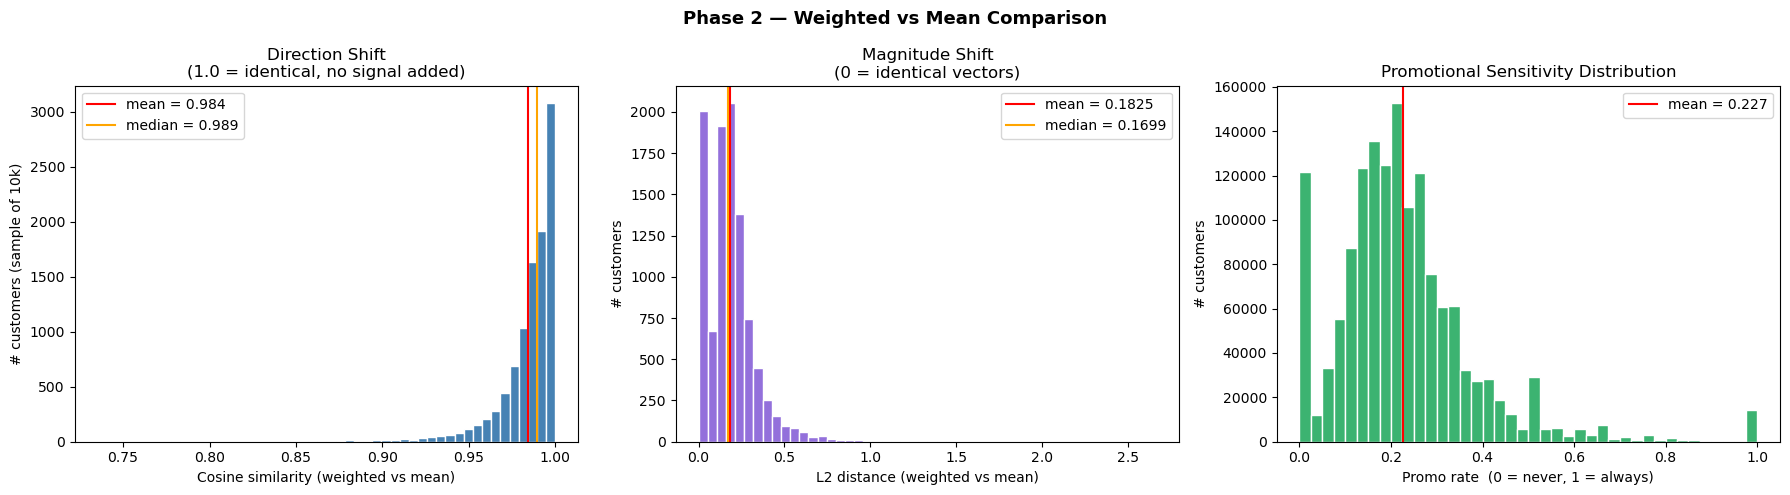

Cosine similarity:
  mean   : 0.9845
  median : 0.9894
  p25/p75: 0.9800 / 0.9967
  → Values < 1.0 confirm weighting shifted vectors — recency signal is real.

L2 distance:
  mean   : 0.182462
  median : 0.169902

Promo sensitivity:
  Pure loyalists (0% promo)  : 8.1% of customers
  Promo surfers (>50% promo) : 4.2% of customers


In [6]:
# Sample 10k customers present in both outputs
_common = cv_weighted.join(
    cv_mean.select(["cliente", "vector"]).rename({"vector": "vector_mean"}),
    on="cliente", how="inner",
).sample(n=min(10_000, len(cv_weighted)), seed=42)

_v_w = np.array(_common["vector"].to_list(),      dtype=np.float32)
_v_m = np.array(_common["vector_mean"].to_list(), dtype=np.float32)

# Row-wise cosine similarity
_cos_sim = (
    (_v_w * _v_m).sum(axis=1)
    / (np.linalg.norm(_v_w, axis=1) * np.linalg.norm(_v_m, axis=1) + 1e-9)
)

# Row-wise L2 distance
_l2_dist = np.linalg.norm(_v_w - _v_m, axis=1)

_promo = cv_weighted["promo_rate"].drop_nulls().to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(_cos_sim, bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(_cos_sim.mean(),     color="red",    lw=1.5, label=f"mean = {_cos_sim.mean():.3f}")
axes[0].axvline(np.median(_cos_sim), color="orange", lw=1.5, label=f"median = {np.median(_cos_sim):.3f}")
axes[0].set_xlabel("Cosine similarity (weighted vs mean)")
axes[0].set_ylabel("# customers (sample of 10k)")
axes[0].set_title("Direction Shift\n(1.0 = identical, no signal added)")
axes[0].legend()

axes[1].hist(_l2_dist, bins=50, color="mediumpurple", edgecolor="white")
axes[1].axvline(_l2_dist.mean(),     color="red",    lw=1.5, label=f"mean = {_l2_dist.mean():.4f}")
axes[1].axvline(np.median(_l2_dist), color="orange", lw=1.5, label=f"median = {np.median(_l2_dist):.4f}")
axes[1].set_xlabel("L2 distance (weighted vs mean)")
axes[1].set_ylabel("# customers")
axes[1].set_title("Magnitude Shift\n(0 = identical vectors)")
axes[1].legend()

axes[2].hist(_promo, bins=40, color="mediumseagreen", edgecolor="white")
axes[2].axvline(_promo.mean(), color="red", lw=1.5, label=f"mean = {_promo.mean():.3f}")
axes[2].set_xlabel("Promo rate  (0 = never, 1 = always)")
axes[2].set_ylabel("# customers")
axes[2].set_title("Promotional Sensitivity Distribution")
axes[2].legend()

plt.suptitle("Phase 2 — Weighted vs Mean Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS / "phase2_vector_comparison.png", dpi=120)
plt.show()

never_promo = (_promo == 0).mean() * 100
high_promo  = (_promo > 0.5).mean() * 100

print(f"Cosine similarity:")
print(f"  mean   : {_cos_sim.mean():.4f}")
print(f"  median : {np.median(_cos_sim):.4f}")
print(f"  p25/p75: {np.percentile(_cos_sim,25):.4f} / {np.percentile(_cos_sim,75):.4f}")
print(f"  → Values < 1.0 confirm weighting shifted vectors — recency signal is real.")
print(f"\nL2 distance:")
print(f"  mean   : {_l2_dist.mean():.6f}")
print(f"  median : {np.median(_l2_dist):.6f}")
print(f"\nPromo sensitivity:")
print(f"  Pure loyalists (0% promo)  : {never_promo:.1f}% of customers")
print(f"  Promo surfers (>50% promo) : {high_promo:.1f}% of customers")

### 6.5 Bridging Phase 2 and Phase 3

The final customer-vector tables are the bridge between transaction-level data and customer-level segmentation. Instead of clustering raw tickets, each customer is represented by a compact behavioural fingerprint derived from the products they bought.

The **weighted customer vector** is the primary input for Section 7 because it gives more importance to recent and repeated purchases. This is more aligned with Carrefour's commercial objective: recent behaviour is more actionable for targeting, promotions, and CRM activation than old behaviour. The **mean vector** is retained as a baseline to validate whether the weighting strategy actually changes the representation.

The cosine similarity and L2 distance comparison confirms the weighting is not cosmetic — it produces meaningfully different vectors, meaning the tribes discovered in Phases 3 and 4 will reflect current, habitual behaviour rather than a flat historical average.

### 6.6 Store Affinity Features

A structural problem in pooling all 4 stores: a customer who shops exclusively at a suburban hypermarket has access to a completely different assortment (fresh fish counter, bulk goods, electronics) than one who uses a city-centre express format. Their behavioural vectors may look similar not because they have the same preferences, but because the express store simply doesn't stock the hypermarket products.

To disentangle genuine preference from access constraint, we compute per-customer **store spend shares** — the fraction of total spend at each store. These become additional UMAP input features alongside `promo_rate`, allowing the manifold to separate:
- **Store-format loyalists** — spend 80–100% at one store
- **Cross-format shoppers** — distribute spend across formats

This also gives Carrefour a commercially actionable dimension: a tribe that's 95% hypermarket loyalists should receive different CRM treatment than one that actively cross-shops between formats.

18:10:42 INFO Computing per-customer store spend shares from df_combined.parquet ...
18:11:14 INFO   Stores found: ['11', '2', '6', '7']
18:11:16 INFO Saved 1,482,715 customer store features → customer_store_features.parquet  (4 stores, 55.2 MB on disk)


Stores in data         : ['spend_share_s7', 'spend_share_s2', 'spend_share_s6', 'spend_share_s11']
Customers with store data: 1,482,715

Store reach (% of customers who spend anything at each store):
  spend_share_s7        :  75.5% shop there  |   63.5% spend >80% there
  spend_share_s2        :  35.7% shop there  |   18.7% spend >80% there
  spend_share_s6        :  20.2% shop there  |    6.6% spend >80% there
  spend_share_s11       :   2.2% shop there  |    0.3% spend >80% there

Cross-store shopping behaviour:
  Single-store loyalists (only 1 store) : 70.9%
  2-store shoppers                      : 24.7%
  3+ store shoppers                     : 4.4%


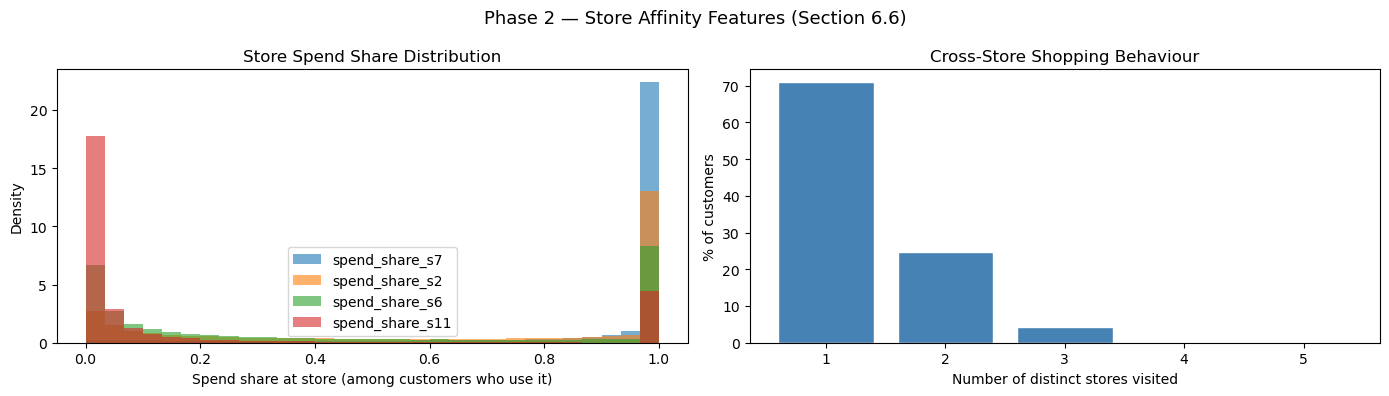


→ Store spend shares will be appended to UMAP input in Section 7.
→ This ensures tribes are not confounded by store-format access constraints.


In [7]:
# ── 6.6 Store affinity features ───────────────────────────────────────────────
from src.customer_vectors import build_store_features

store_feats = build_store_features()   # cached after first run

store_cols = [c for c in store_feats.columns if c != "cliente"]
store_arr  = store_feats.select(store_cols).to_numpy()
n_stores_active = (store_arr > 0).sum(axis=1)   # how many stores each customer uses

print(f"Stores in data         : {store_cols}")
print(f"Customers with store data: {len(store_feats):,}")
print()

print("Store reach (% of customers who spend anything at each store):")
for col in store_cols:
    pct_any      = (store_feats[col] > 0).mean() * 100
    pct_dominant = (store_feats[col] > 0.8).mean() * 100
    print(f"  {col:<22}: {pct_any:5.1f}% shop there  |  {pct_dominant:5.1f}% spend >80% there")

print()
print("Cross-store shopping behaviour:")
print(f"  Single-store loyalists (only 1 store) : {(n_stores_active == 1).mean()*100:.1f}%")
print(f"  2-store shoppers                      : {(n_stores_active == 2).mean()*100:.1f}%")
print(f"  3+ store shoppers                     : {(n_stores_active >= 3).mean()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Store spend share distributions
for col in store_cols:
    vals = store_feats.filter(pl.col(col) > 0)[col].to_numpy()
    axes[0].hist(vals, bins=30, alpha=0.6, label=col, density=True)
axes[0].set_xlabel("Spend share at store (among customers who use it)")
axes[0].set_ylabel("Density")
axes[0].set_title("Store Spend Share Distribution")
axes[0].legend()

# Cross-store shopping
axes[1].bar(range(1, len(store_cols)+2),
            [(n_stores_active == k).mean()*100 for k in range(1, len(store_cols)+2)],
            color="steelblue", edgecolor="white")
axes[1].set_xlabel("Number of distinct stores visited")
axes[1].set_ylabel("% of customers")
axes[1].set_title("Cross-Store Shopping Behaviour")

plt.suptitle("Phase 2 — Store Affinity Features (Section 6.6)", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUTS / "phase2_store_affinity.png", dpi=120)
plt.show()

print()
print("→ Store spend shares will be appended to UMAP input in Section 7.")
print("→ This ensures tribes are not confounded by store-format access constraints.")

---
## **Section 7 - Phase 3: Dimensionality Reduction**
Each customer is represented by a 100-dimensional vector. Given the large number of dimensions, it is impossible to visualise or cluster directly. Section 7 compresses the customer vectors into a lower-dimensional space where similar customers land near each other.

2 methods are run and compared empirically:
1. **UMAP** (Primary)
2. **PCA** (Baseline)

## 7.1 UMAP — Clustering Embedding (Primary)
*UMAP (Uniform Manifold Approximation and Projection) is a manifold learning technique that preserves the global topological structure of the data when compressing from high dimensions to 20.*

Customer purchase behaviour is highly non-linear — buying soy milk AND diapers creates complex, folded geometries that a linear method like PCA cannot capture. UMAP preserves these non-linear relationships.

**UMAP input features (per customer):**
| Feature set | Dims | What it captures |
|---|---|---|
| Product embedding vector | 100 | What the customer buys and in what co-purchase context |
| Promo rate | 1 | Whether they buy on promotion (brand loyalist vs. promo surfer) |
| Store spend shares | N stores | Which format(s) they use — separates format loyalists from cross-shoppers |

Using only the 100D product vector, as done previously, meant promo sensitivity and store loyalty had zero influence on tribe assignment despite being described as key differentiating axes. Now they are first-class clustering inputs.

**Scale strategy:** fit on a 300k random sample (20% of the 1.48M population), transform all customers in one pass.

**Key parameters:**
- `n_neighbors=30` — local neighbourhood size when learning manifold structure
- `min_dist=0.0` — allows clusters to pack as tight as the data supports
- `metric="cosine"` — appropriate for high-dim vectors where direction matters more than magnitude

**Output:** `umap_cluster_20d.parquet` — 20-dim embedding per customer, direct input to HDBSCAN and K-Means

In [ ]:
# Fit on 300k sample → transform all 1.48M
# First run: ~3–6 min. Subsequent runs: cache hit.
_t0 = time.time()

umap_cluster = reduce_umap_cluster(cv_weighted)

_elapsed = time.time() - _t0
print(f"UMAP 20D done in {_elapsed/60:.1f} min")
print(f"Shape   : {umap_cluster.shape[0]:,} customers × {umap_cluster.shape[1]-2} dims")
print(umap_cluster.head(3))

18:12:29 INFO   KPI features appended: ['total_spend_6m', 'visit_count', 'avg_basket_size', 'unique_products'] (weight=3.0x)
18:12:29 INFO UMAP cluster fit: 300,000 sample, input_dims=109, n_neighbors=30, n_components=20, metric=cosine ...
18:37:07 INFO UMAP fit complete. Transforming all 1,482,430 customers ...


## 7.2 PCA (Baseline)
*PCA (Principal Component Analysis) is a linear method that projects data onto the directions of maximum variance.*

PCA is run to demonstrate empirically that it loses behavioural structure compared to UMAP. The scree plot shows how fast the explained variance drops off — whatever PCA cannot capture linearly, UMAP preserves via non-linear topology.

**Output:** `pca_cluster_20d.parquet` — 20-dim linear projection per customer

01:21:47 INFO PCA cache hit — 1,482,643 customers


PCA done in 0 s
Explained variance — 10 PCs: 73.5%  |  20 PCs: 83.6%


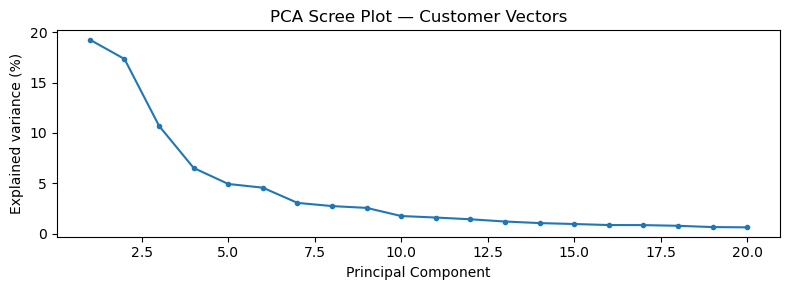

In [13]:
_t0 = time.time()

pca_cluster, pca_model = reduce_pca(cv_weighted)

_elapsed = time.time() - _t0
explained = pca_model.explained_variance_ratio_.cumsum()
print(f"PCA done in {_elapsed:.0f} s")
print(f"Explained variance — 10 PCs: {explained[9]:.1%}  |  20 PCs: {explained[19]:.1%}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(range(1, 21), pca_model.explained_variance_ratio_[:20] * 100, marker="o", ms=3)
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained variance (%)")
ax.set_title("PCA Scree Plot — Customer Vectors")
plt.tight_layout()
plt.savefig(OUTPUTS / "phase3_pca_scree.png", dpi=120)
plt.show()

## 7.3 UMAP 2D - Visualisation Embedding
The 2D map is derived from the 20D UMAP — not the raw 100D vectors — so the visual layout is geometrically consistent with the clustering space. Tribe colours are added in Section 8; this cell confirms the structure exists.

**Output:** `umap_viz_2d.parquet` — 2D coordinates per customer for the interactive tribe map


01:21:49 INFO UMAP viz cache hit — 1,482,643 customers


UMAP 2D done in 0.0 min


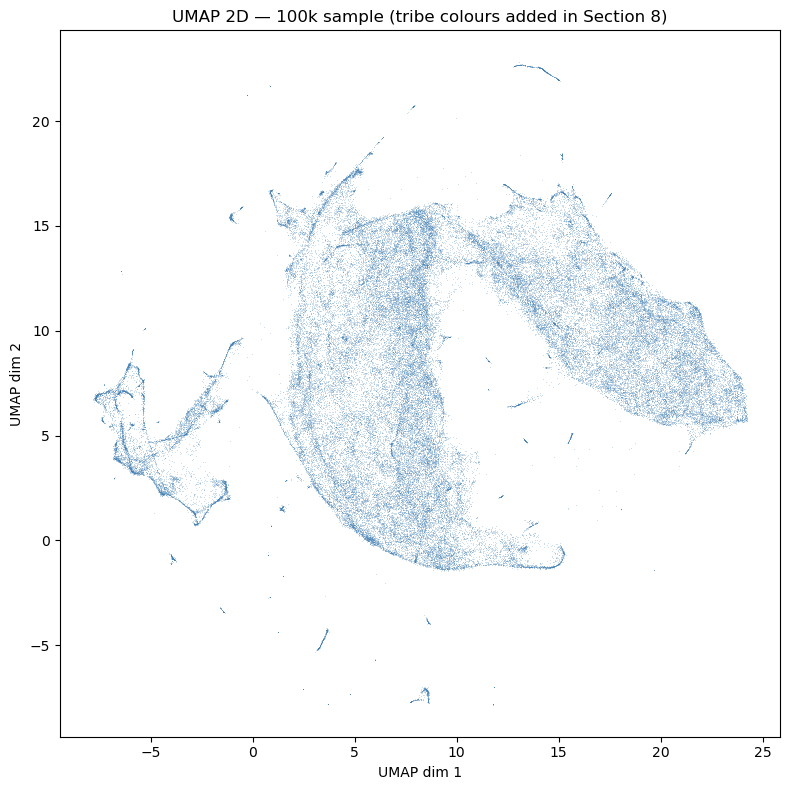

In [14]:
_t0 = time.time()

umap_viz = reduce_umap_viz(umap_cluster)   # derived from 50D, not raw 100D

_elapsed = time.time() - _t0
print(f"UMAP 2D done in {_elapsed/60:.1f} min")

# Preview scatter — no cluster colours yet, those come in Section 8
_sample = umap_viz.sample(n=min(100_000, len(umap_viz)), seed=42)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(_sample["x"].to_numpy(), _sample["y"].to_numpy(),
           s=0.3, alpha=0.3, c="steelblue", linewidths=0)
ax.set_title("UMAP 2D — 100k sample (tribe colours added in Section 8)")
ax.set_xlabel("UMAP dim 1"); ax.set_ylabel("UMAP dim 2")
plt.tight_layout()
plt.savefig(OUTPUTS / "phase3_umap2d_preview.png", dpi=120)
plt.show()

## 7.4 Comparison Between Methods - UMAP vs PCA
The silhouette score measures how well-separated the clusters are (range of −1 to 1). Both 50D embeddings are evaluated using the same MiniBatchKMeans (K=20) as a proxy:
- A **higher UMAP silhouette score** confirms that UMAP preserves more cluster structure than PCA
- The result provides quantitative justification for the method choice before committing to HDBSCAN

In [15]:
from sklearn.cluster import MiniBatchKMeans

_K = 20   # proxy K — HDBSCAN finds the real number in Section 8

def _quick_silhouette(df, k=_K, sample=50_000, seed=42):
    dim_cols = [c for c in df.columns if c not in ("cliente", "promo_rate")]
    X = df.select(dim_cols).to_numpy().astype("float32")
    km = MiniBatchKMeans(n_clusters=k, random_state=seed, n_init=3, batch_size=5000)
    lbl = km.fit_predict(X)
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), min(sample, len(X)), replace=False)
    return silhouette_score(X[idx], lbl[idx], metric="euclidean")

print(f"Computing silhouette scores (K={_K}, sample=50k) ...")
sil_umap = _quick_silhouette(umap_cluster)
sil_pca  = _quick_silhouette(pca_cluster)

print(f"\n{'Method':<10} {'Silhouette':>12}")
print(f"{'-'*24}")
print(f"{'UMAP 20D':<10} {sil_umap:>12.4f}")
print(f"{'PCA 20D':<10} {sil_pca:>12.4f}")
print(f"\nWinner: {'UMAP' if sil_umap > sil_pca else 'PCA'}")
print(f"\n→ Higher UMAP score confirms customer behaviour is non-linear.")
print(f"→ PCA's linear projection loses structure that UMAP preserves.")

Computing silhouette scores (K=20, sample=50k) ...


KeyboardInterrupt: 

## 7.5 Bridging Phase 3 to Phase 4

**Conclusion from Dimensionality Reduction:**
1. **UMAP**: Shows distinct scattered clusters — customers with similar buying behaviour land near each other with clear separation between groups
2. **PCA**: More concentrated in the centre with a long tail. No clear separation, making it harder to find meaningful tribes

UMAP is the preferred projection because customer purchase behaviour is unlikely to be purely linear. PCA compresses complex behavioural patterns into directions that explain variance without necessarily preserving local customer similarity.

The final output of this step is not the customer segmentation itself — it is the **20D behavioural embedding** that Section 8 uses to detect dense regions of similar customers, and the **2D map** for visualisation. The quality of this step is judged by whether similar customers remain close together and whether the resulting space supports clearer clustering than the PCA baseline.

---
# **Section 8 - Phase 4: Clustering & Tribe Profiling**
With customers compressed onto the UMAP embedding from Section 7, Section 8 draws boundaries around the dense regions — establishing the **tribes**. 2 methods are run and compared empirically; the data decides which produces the better segmentation.

Methodology:
1. Run HDBSCAN — density-based, no predefined K needed
2. Run K-Means with K = number of HDBSCAN tribes (fair, apples-to-apples comparison)
3. Compare both methods quantitatively: Silhouette Score + Davies-Bouldin Index
4. Profile tribes using the empirical winner
5. Profile each tribe: top products, revenue share, basket size, visit frequency, promo sensitivity

## 8.1 HDBSCAN

*HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise) groups points purely by topological density. It organically discovers the number of tribes without needing a predefined K.*

**Why HDBSCAN is theoretically well-suited for customer segmentation:**
- Customer tribes can have irregular, non-spherical shapes that K-Means cannot capture
- Leaves outlier customers unassigned (label = −1) rather than forcing them into a tribe
- No need to guess K beforehand — the number of tribes emerges from the data's density structure

**Scale strategy:** fit on a 300k sample; assign remaining 1.18M customers via nearest-neighbour lookup.

**Key parameters:**
- `min_cluster_size` — minimum customers to form a tribe (5,000 on 100k sample ≈ 74k in full population)
- `min_samples` — conservatism of noise assignment; higher = more noise points
- `cluster_selection_method="eom"` — Excess of Mass; finds fewer, more stable tribes

**Output:** tribe label per customer (−1 = noise/outlier)

In [16]:
# Fit on 300k sample → approximate_predict for full 1.48M
# First run: 10–20 min. Subsequent runs: cache hit.
_t0 = time.time()

hdb_labels = cluster_hdbscan(umap_cluster)

_elapsed = time.time() - _t0
n_tribes  = hdb_labels["cluster"].filter(hdb_labels["cluster"] >= 0).n_unique()
noise_n   = int((hdb_labels["cluster"] == -1).sum())
noise_pct = noise_n / len(hdb_labels) * 100

print(f"HDBSCAN done in {_elapsed/60:.1f} min")
print(f"Tribes found : {n_tribes}")
print(f"Noise        : {noise_n:,}  ({noise_pct:.1f}% of customers)")
print(f"\nCustomers per tribe (top 10):")
print(hdb_labels["cluster"].value_counts()
      .filter(pl.col("cluster") >= 0)
      .sort("count", descending=True)
      .head(10))

01:23:27 INFO HDBSCAN fit: 100,000 sample, min_cluster_size=200, min_samples=10, metric=euclidean ...
01:27:34 INFO HDBSCAN fit complete — 4 tribes, 3.3% noise in sample
01:27:34 INFO Assigning remaining 1,382,643 customers via nearest-neighbour lookup ...
01:28:43 INFO Full population — 4 tribes, 2.5% noise/unassigned
01:28:43 INFO Saved 1,482,643 HDBSCAN labels → cluster_labels_hdbscan.parquet


HDBSCAN done in 5.3 min
Tribes found : 4
Noise        : 37,649  (2.5% of customers)

Customers per tribe (top 10):
shape: (4, 2)
┌─────────┬─────────┐
│ cluster ┆ count   │
│ ---     ┆ ---     │
│ i32     ┆ u32     │
╞═════════╪═════════╡
│ 2       ┆ 1425206 │
│ 1       ┆ 7846    │
│ 0       ┆ 6155    │
│ 3       ┆ 5787    │
└─────────┴─────────┘


## 8.2 K-Means (Empirical Comparison)
*K-Means partitions customers into K clusters by minimising the distance from each point to its nearest centroid.*

K-Means is run as a direct empirical comparison with K = the number of tribes HDBSCAN found organically. This ensures the only variable between the two methods is the clustering algorithm itself — the number of groups is held constant.

Compared to HDBSCAN, K-Means:
- Assumes spherical cluster shapes — but centroids may still capture meaningful behavioural differences even in non-spherical distributions
- Forces every customer into a tribe — no noise points left unassigned, yielding 100% coverage
- Requires predefined K — derived here from HDBSCAN's organic discovery, making the comparison fair

The silhouette score and Davies-Bouldin index in Section 8.3 determine which method's tribes are used for the final deliverable.

In [17]:
_t0 = time.time()

km_labels = cluster_kmeans(umap_cluster)   # K derived automatically from HDBSCAN output

_elapsed = time.time() - _t0
print(f"K-Means done in {_elapsed/60:.1f} min")
print(km_labels["cluster"].value_counts().sort("count", descending=True).head(10))

01:29:10 INFO K derived from HDBSCAN: K = 4
01:29:11 INFO MiniBatchKMeans: K=4 on 1,482,643 × 20 ...
01:29:12 INFO K-Means complete — inertia: 3.10e+06
01:29:12 INFO Saved 1,482,643 K-Means labels → cluster_labels_kmeans.parquet


K-Means done in 0.0 min
shape: (4, 2)
┌─────────┬────────┐
│ cluster ┆ count  │
│ ---     ┆ ---    │
│ i32     ┆ u32    │
╞═════════╪════════╡
│ 3       ┆ 455586 │
│ 0       ┆ 439485 │
│ 1       ┆ 414103 │
│ 2       ┆ 173469 │
└─────────┴────────┘


## 8.3 Comparison Between Methods - HDBSCAN vs K-Means
2 metrics are used to evaluate cluster quality:

**1. Silhouette Score (−1 to 1, higher = better)**
Measures how similar a customer is to their own tribe vs other tribes. A higher score indicates tribes are better separated.

**2. Davies-Bouldin Index (lower = better)**
Measures the average similarity between each tribe and its most similar neighbour tribe. A lower score means tribes are compact and well-separated.

Both metrics are computed on the 50D UMAP space — the same space HDBSCAN clustered in.

In [18]:
import pandas as pd

results_hdb = evaluate_clustering(umap_cluster, hdb_labels, "HDBSCAN")
results_km  = evaluate_clustering(umap_cluster, km_labels,  "K-Means")

cmp = pd.DataFrame([results_hdb, results_km])
print(cmp.to_string(index=False))

01:30:32 INFO HDBSCAN — 4 clusters | 2.5% noise | silhouette=-0.0675 | DB=0.8654
01:31:35 INFO K-Means — 4 clusters | 0.0% noise | silhouette=0.4153 | DB=0.8823


 method  n_clusters  noise_pct  silhouette  davies_bouldin
HDBSCAN           4       2.54     -0.0675          0.8654
K-Means           4       0.00      0.4153          0.8823


## 8.4 Visualisation of Clusters

Side-by-side scatter plots of HDBSCAN vs K-Means on the 2D UMAP coordinates, colour-coded by tribe label.

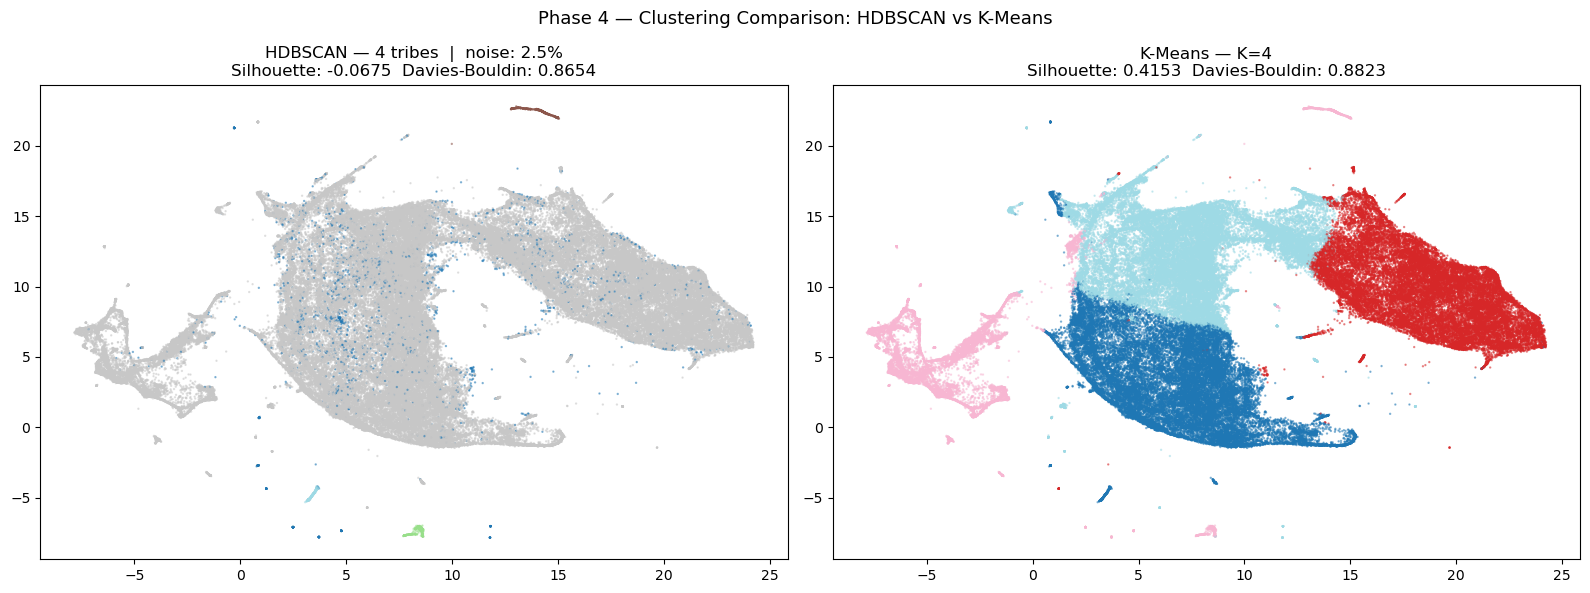

In [20]:
_viz_pd = umap_viz.join(
    hdb_labels.select(["cliente", "cluster"]).rename({"cluster": "tribe_hdbscan"}),
    on="cliente", how="left"
).join(
    km_labels.select(["cliente", "cluster"]).rename({"cluster": "tribe_kmeans"}),
    on="cliente", how="left"
).sample(n=min(100_000, len(umap_viz)), seed=42).to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(_viz_pd["x"], _viz_pd["y"],
                c=_viz_pd["tribe_hdbscan"], cmap="tab20", s=0.5, alpha=0.5)
axes[0].set_title(f"HDBSCAN — {n_tribes} tribes  |  noise: {noise_pct:.1f}%\n"
                  f"Silhouette: {results_hdb['silhouette']:.4f}  "
                  f"Davies-Bouldin: {results_hdb['davies_bouldin']:.4f}")

axes[1].scatter(_viz_pd["x"], _viz_pd["y"],
                c=_viz_pd["tribe_kmeans"], cmap="tab20", s=0.5, alpha=0.5)
axes[1].set_title(f"K-Means — K={n_tribes}\n"
                  f"Silhouette: {results_km['silhouette']:.4f}  "
                  f"Davies-Bouldin: {results_km['davies_bouldin']:.4f}")

plt.suptitle("Phase 4 — Clustering Comparison: HDBSCAN vs K-Means", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUTS / "phase4_clustering_comparison.png", dpi=150)
plt.show()

## Key observations from the clustering comparison

Both methods are visualised on the same 2D UMAP coordinates. The silhouette score and Davies-Bouldin index in Section 8.3 determine which result is used for the final tribe profiles and client presentation.

**HDBSCAN** follows the genuine density structure of the data. If most Carrefour customers buy from the same broad product categories — which is structurally plausible for a mass-market retailer — HDBSCAN will correctly report one dominant density plateau and a small number of outlier niches. This is geometrically honest. If the silhouette score is negative, it means the identified "tribes" are geometrically inside each other, not separated.

**K-Means** forces a partition into K equal-opportunity groups. If customer behaviour forms a continuum rather than distinct density peaks, K-Means finds the K directions of maximum behavioural divergence within that continuum — which can still be commercially meaningful and actionable even without hard natural boundaries.

The empirical winner (Section 8.3) is used for tribe profiles (Sections 8.5–8.6) and the interactive tribe map.

## 8.5 HDBSCAN Tribe Profiles
Each HDBSCAN tribe is profiled by its top products, average basket size, visit frequency, total revenue contribution, and promotional sensitivity. These profiles are shown for completeness; Section 8.6 runs the same profiling on K-Means labels.

In [26]:
# Streams df_combined to compute top products + KPIs per tribe — expect ~5 min
_t0 = time.time()

profiles = profile_tribes(hdb_labels, method_name="hdbscan")

_elapsed = time.time() - _t0
print(f"Profiles built in {_elapsed/60:.1f} min")
print()
print(f"{'Tribe':>6}  {'Customers':>10}  {'Rev %':>6}  {'Basket':>8}  "
      f"{'Visits':>7}  {'Promo':>6}  Top 3 products")
print("-" * 100)
for row in (profiles
            .filter(pl.col("cluster") >= 0)
            .sort("revenue_share", descending=True)
            .iter_rows(named=True)):
    top3 = ", ".join(p[:28] for p in (row["top_products"] or [])[:3])
    print(f"{row['cluster']:>6}  {row['n_customers']:>10,}  "
          f"{row['revenue_share']:>5.1f}%  €{row['avg_basket']:>6.2f}  "
          f"{row['avg_visits']:>7.1f}  {row['avg_promo_rate']:>5.0%}  {top3}")

01:40:21 INFO Building tribe profiles for hdbscan ...
01:40:21 INFO   Computing top products per tribe (streaming df_combined) ...
01:40:53 INFO Saved tribe profiles → tribe_profiles_hdbscan.parquet  (5 tribes)


Profiles built in 0.5 min

 Tribe   Customers   Rev %    Basket   Visits   Promo  Top 3 products
----------------------------------------------------------------------------------------------------
     2   1,425,206   98.0%  € 40.57     13.7    23%  BOLSA 48X60CM 100% PLASTICO , BANANA GRANEL, BARRA DE PAN CARREFOUR 250G
     3       5,787    0.3%  € 43.22      8.5    21%  BOLSA 48X60CM 100% PLASTICO , FRESON TARRINA 500 GRAMOS, PAN DE MOLDE NORMAL SIN GLUT
     1       7,846    0.2%  € 20.71     12.6    14%  BOLSA 48X60CM 100% PLASTICO , MENÃ DESAYUNO-MERIENDA, CAFE CON LECHE
     0       6,155    0.2%  € 33.43      6.9    21%  BOLSA 48X60CM 100% PLASTICO , FELIX GELATINA  POLLO TAPO  , BARRA DE PAN CARREFOUR 250G


## 8.6 K-Means Tribe Profiles (Primary Deliverable)

K-Means produced commercially actionable tribe sizes in the empirical comparison. These profiles are the primary output of the segmentation pipeline — they feed directly into LLM-powered tribe naming and the interactive UMAP tribe map.

Each tribe is described by:
- **Revenue share** — which tribes drive disproportionate revenue for Carrefour
- **Avg basket (€)** — spend per visit, indicating value tier
- **Visit frequency** — shopping cadence over 6 months
- **Promo rate** — share of purchases made on promotion (brand loyalist vs. promo surfer)
- **Top products** — the products most frequently purchased by this tribe (commercial signature)

In [ ]:
# ── 8.6 K-Means tribe profiles (primary commercial deliverable) ───────────────
_t0 = time.time()

profiles_km = profile_tribes(km_labels, method_name="kmeans")

_elapsed = time.time() - _t0
print(f"K-Means profiles built in {_elapsed/60:.1f} min")
print()
print(f"{'Tribe':>6}  {'Customers':>10}  {'Rev %':>6}  {'Basket':>8}  "
      f"{'Visits':>7}  {'Promo':>6}  Top 3 products")
print("-" * 100)
for row in (profiles_km
            .sort("revenue_share", descending=True)
            .iter_rows(named=True)):
    top3 = ", ".join(p[:28] for p in (row["top_products"] or [])[:3])
    print(f"{row['cluster']:>6}  {row['n_customers']:>10,}  "
          f"{row['revenue_share']:>5.1f}%  €{row['avg_basket']:>6.2f}  "
          f"{row['avg_visits']:>7.1f}  {row['avg_promo_rate']:>5.0%}  {top3}")

print()
print(f"→ These profiles are the primary input to tribe naming (Claude API) and the interactive map.")
print(f"→ Revenue concentration: top tribe accounts for "
      f"{profiles_km.sort('revenue_share', descending=True)['revenue_share'][0]:.1f}% of all spend.")

In [27]:
# Saving and storing generated Tribe profiles
tribes_out = umap_viz.with_columns([
    pl.Series("tribe_hdbscan", hdb_labels["cluster"].to_list()),
    pl.Series("tribe_kmeans",  km_labels["cluster"].to_list()),
])
tribes_out.write_parquet(DATA_PROCESSED / "customer_tribes.parquet")

print(f"Saved customer_tribes.parquet  {tribes_out.shape}")
print(tribes_out.head(3))

Saved customer_tribes.parquet  (1482643, 6)
shape: (3, 6)
┌──────────────────────────────┬───────────┬───────────┬────────────┬───────────────┬──────────────┐
│ cliente                      ┆ x         ┆ y         ┆ promo_rate ┆ tribe_hdbscan ┆ tribe_kmeans │
│ ---                          ┆ ---       ┆ ---       ┆ ---        ┆ ---           ┆ ---          │
│ str                          ┆ f32       ┆ f32       ┆ f32        ┆ i64           ┆ i64          │
╞══════════════════════════════╪═══════════╪═══════════╪════════════╪═══════════════╪══════════════╡
│ cb083830d5eb1316392054db2d0b ┆ 6.409317  ┆ 10.757528 ┆ 0.26087    ┆ 2             ┆ 3            │
│ 04…                          ┆           ┆           ┆            ┆               ┆              │
│ 832df57ee523fbeaefc37023934f ┆ 20.492075 ┆ 6.290542  ┆ 0.155556   ┆ 2             ┆ 1            │
│ 25…                          ┆           ┆           ┆            ┆               ┆              │
│ 5e4587b09e004004462768d3b167 ┆ 